<a href="https://colab.research.google.com/github/clobos/ECO5056_2026/blob/main/Aula_03_Validacao_Boosting_Interpretacao.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Aula 03 — Validação, Generalização, Boosting e Interpretação
**Base real ambiental:** `airquality`, Nova York, maio–setembro de 1973. **Pergunta:** o desempenho estimado muda quando respeitamos a ordem temporal?

## 1. Objetivos da aula
Diagnosticar overfitting/leakage; comparar validação aleatória, temporal e por grupos; ajustar Random Forest e Gradient Boosting; usar importância por permutação; discutir previsão versus causalidade.

## 2. Pergunta ecológica
**Até que ponto radiação solar, vento e temperatura permitem predizer ozônio diário, e quão sensível é a avaliação ao desenho de validação?**

## 3. Fonte dos dados
R `datasets::airquality`: 153 dias, maio–setembro de 1973. Ozônio: New York State Department of Conservation; meteorologia: National Weather Service. Referência: Chambers et al. (1983), *Graphical Methods for Data Analysis*.

## 4. Importação das bibliotecas

In [1]:
from pathlib import Path
import numpy as np,pandas as pd,matplotlib.pyplot as plt,sklearn
from sklearn.model_selection import KFold,TimeSeriesSplit,GroupKFold,cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestRegressor,GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error,root_mean_squared_error,r2_score
from sklearn.inspection import permutation_importance,PartialDependenceDisplay
np.random.seed(42)
print("scikit-learn",sklearn.__version__)

scikit-learn 1.6.1


## 5. Download ou carregamento dos dados

In [2]:
URL="https://raw.githubusercontent.com/vincentarelbundock/Rdatasets/master/csv/datasets/airquality.csv"
try:
    dados=pd.read_csv(URL); fonte_execucao="URL pública"
except Exception:
    dados=pd.read_csv(Path("/mnt/data/airquality.csv")); fonte_execucao="fallback local de QA"
if "rownames" in dados: dados=dados.drop(columns="rownames")
dados["Date"]=pd.to_datetime(dict(year=1973,month=dados.Month,day=dados.Day))
dados=dados.sort_values("Date").reset_index(drop=True)
print(fonte_execucao,dados.shape)

URL pública (153, 7)


## 6. Conhecendo a base

In [3]:
display(dados.head())
print(dados.isna().sum())
print(dados.describe().round(2))

,Ozone,Solar.R,Wind,Temp,Month,Day,Date
0,41.0,190.0,7.4,67,5,1,1973-05-01
1,36.0,118.0,8.0,72,5,2,1973-05-02
2,12.0,149.0,12.6,74,5,3,1973-05-03
3,18.0,313.0,11.5,62,5,4,1973-05-04
4,NaN,NaN,14.3,56,5,5,1973-05-05


Ozone      37
Solar.R     7
Wind        0
Temp        0
Month       0
Day         0
Date        0
dtype: int64
        Ozone  Solar.R    Wind    Temp   Month     Day                 Date
count  116.00   146.00  153.00  153.00  153.00  153.00                  153
mean    42.13   185.93    9.96   77.88    6.99   15.80  1973-07-16 00:00:00
min      1.00     7.00    1.70   56.00    5.00    1.00  1973-05-01 00:00:00
25%     18.00   115.75    7.40   72.00    6.00    8.00  1973-06-08 00:00:00
50%     31.50   205.00    9.70   79.00    7.00   16.00  1973-07-16 00:00:00
75%     63.25   258.75   11.50   85.00    8.00   23.00  1973-08-23 00:00:00
max    168.00   334.00   20.70   97.00    9.00   31.00  1973-09-30 00:00:00
std     32.99    90.06    3.52    9.47    1.42    8.86                  NaN


## 7. Análise exploratória

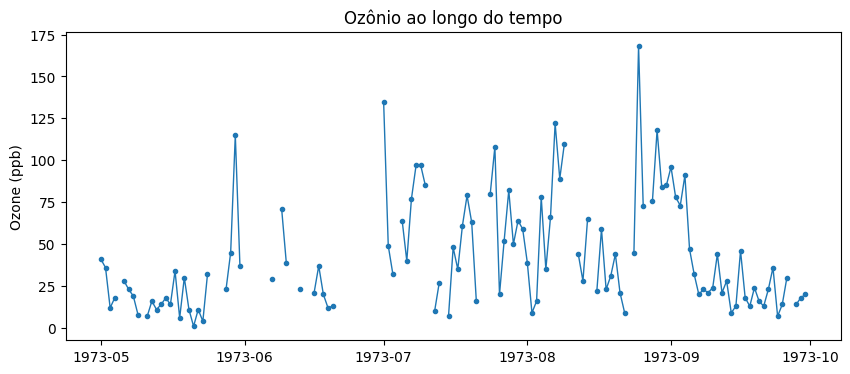

In [4]:
fig,ax=plt.subplots(figsize=(10,4)); ax.plot(dados.Date,dados.Ozone,marker="o",ms=3,lw=1); ax.set(title="Ozônio ao longo do tempo",ylabel="Ozone (ppb)"); plt.show()

## 8. Preparação dos dados
Linhas sem `Ozone` não podem treinar um regressor supervisionado. `Solar.R` ausente é imputada **dentro** da pipeline. A ordem temporal é mantida.

In [5]:
analise=dados.dropna(subset=["Ozone"]).copy()
features=["Solar.R","Wind","Temp","Month"]
X=analise[features]; y=analise["Ozone"]; grupos=analise["Month"]
print("Dias com resposta:",len(analise))

Dias com resposta: 116


## 9. Construção do modelo

In [6]:
modelos={
"Random Forest":Pipeline([("imp",SimpleImputer(strategy="median")),("m",RandomForestRegressor(n_estimators=500,min_samples_leaf=3,random_state=42,n_jobs=-1))]),
"Gradient Boosting":Pipeline([("imp",SimpleImputer(strategy="median")),("m",GradientBoostingRegressor(n_estimators=200,learning_rate=.03,max_depth=2,min_samples_leaf=4,random_state=42))])
}

## 10. Avaliação
Comparamos KFold aleatório (otimista quando a dependência temporal importa), `TimeSeriesSplit` e `GroupKFold` deixando cada mês fora.

In [7]:
registros=[]
for nome,m in modelos.items():
    esquemas={"KFold aleatório":KFold(5,shuffle=True,random_state=42),"TimeSeriesSplit":TimeSeriesSplit(5)}
    for rot,cv in esquemas.items():
        mae=-cross_val_score(m,X,y,cv=cv,scoring="neg_mean_absolute_error",n_jobs=-1)
        rmse=-cross_val_score(m,X,y,cv=cv,scoring="neg_root_mean_squared_error",n_jobs=-1)
        registros.append([nome,rot,mae.mean(),mae.std(),rmse.mean()])
    gcv=GroupKFold(n_splits=5)
    mae=-cross_val_score(m,X,y,groups=grupos,cv=gcv,scoring="neg_mean_absolute_error",n_jobs=-1)
    registros.append([nome,"GroupKFold por mês",mae.mean(),mae.std(),np.nan])
res=pd.DataFrame(registros,columns=["modelo","validacao","MAE","sd_MAE","RMSE"])
display(res.round(2))

,modelo,validacao,MAE,sd_MAE,RMSE
0,Random Forest,KFold aleatório,12.26,1.96,17.38
1,Random Forest,TimeSeriesSplit,16.67,6.39,24.00
2,Random Forest,GroupKFold por mês,13.12,2.97,NaN
3,Gradient Boosting,KFold aleatório,12.69,1.40,16.71
4,Gradient Boosting,TimeSeriesSplit,17.19,7.25,24.29
5,Gradient Boosting,GroupKFold por mês,12.74,2.43,NaN


## 11. Visualizações

Holdout cronológico — MAE 10.31 RMSE 13.77 R² -0.97


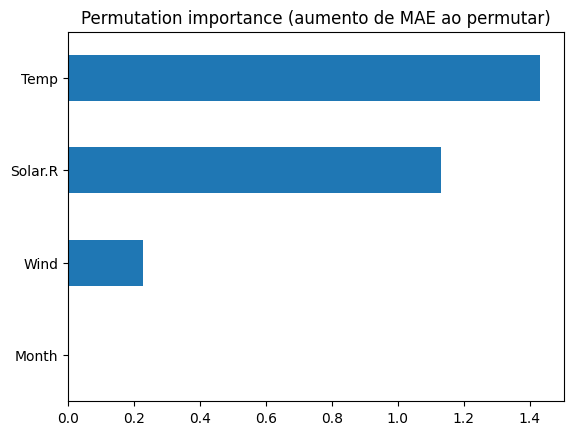

In [8]:
corte=int(.8*len(analise))
Xtr,Xte=X.iloc[:corte],X.iloc[corte:]; ytr,yte=y.iloc[:corte],y.iloc[corte:]
gb=modelos["Gradient Boosting"].fit(Xtr,ytr); pred=gb.predict(Xte)
print("Holdout cronológico — MAE",round(mean_absolute_error(yte,pred),2),"RMSE",round(root_mean_squared_error(yte,pred),2),"R²",round(r2_score(yte,pred),2))
pi=permutation_importance(gb,Xte,yte,n_repeats=30,random_state=42,scoring="neg_mean_absolute_error")
imp=pd.Series(pi.importances_mean,index=features).sort_values()
imp.plot.barh(title="Permutation importance (aumento de MAE ao permutar)"); plt.show()

## 12. Interpretação ecológica
Se o erro temporal for maior que o aleatório, o modelo não “piorou”: a estimativa ficou mais alinhada à tarefa de prever observações futuras. Importância por permutação mede dependência preditiva condicionada ao modelo/dados; não identifica mecanismo causal.

## 13. Limitações
- Série curta, histórica e de uma única estação/área urbana.
- Ozone tem 37 valores ausentes; Solar.R tem ausências.
- `GroupKFold` por mês testa transferência entre meses, mas há apenas cinco grupos.
- O conjunto não contém replicação espacial; validação espacial é discutida conceitualmente, não demonstrada.
- R² pode ser negativo em um holdout temporal de baixa variabilidade mesmo com MAE moderado.

## 14. Exercícios
1. Mostre o workflow errado “imputar tudo → CV” e explique o leakage.
2. Use `TimeSeriesSplit(gap=...)` e discuta dependência de curto prazo.
3. Retire `Month`; as diferenças entre esquemas mudam?
4. Proponha `GroupKFold` para um estudo com 1.000 registros em 20 localidades.
5. Explique por que AUC=0,97 com divisão aleatória não prova generalização espacial.

## 15. Desafio para o estudante
Desenhe uma estratégia de validação para uma espécie amostrada em parcelas, localidades e anos. Defina qual unidade deve permanecer inteira em cada fold, o domínio-alvo de generalização e como seria um teste externo.
### Reprodutibilidade
Todos os procedimentos aleatórios usam semente 42. Ao adaptar o notebook, mantenha a separação entre dados de desenvolvimento e dados de avaliação e registre versões de bibliotecas e decisões analíticas.